In [1]:
# --- Cell 1: Imports, Device, Dataset, Loaders, True Val Split, Weights ---

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

# Paths
train_dir = "train"
test_dir  = "test"
if not os.path.exists(train_dir): raise FileNotFoundError(train_dir)
if not os.path.exists(test_dir):  raise FileNotFoundError(test_dir)

# Class labels
class_labels = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_labels)
print(f"Detected {num_classes} classes: {class_labels}")

# Params
IMG_SIZE = 224
BATCH_SIZE_RESNET = 32
BATCH_SIZE_CNN    = 32
VAL_META_FRAC = 0.10   # 10% of train used ONLY to choose fusion

# Transforms (same for both)
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Dataset
class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.class_to_idx = {cls:i for i,cls in enumerate(class_labels)}

        for cls in class_labels:
            cpath = os.path.join(root_dir, cls)
            for img in os.listdir(cpath):
                f = os.path.join(cpath, img)
                if os.path.isfile(f):
                    self.image_paths.append(f)
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("L")
        y = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, y

train_full = EmotionDataset(train_dir, transform=train_transforms)
test_dataset = EmotionDataset(test_dir, transform=test_transforms)

labels_np = np.array(train_full.labels)

print(f"Train samples: {len(train_full)} | Test samples: {len(test_dataset)}")
print("Class mapping:", train_full.class_to_idx)

# --- True Val Split from TRAIN (for fusion search) ---
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_META_FRAC, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(labels_np)), labels_np))

train_dataset = Subset(train_full, train_idx)
val_meta_dataset = Subset(train_full, val_idx)

print(f"Train-main: {len(train_dataset)} | Val-meta: {len(val_meta_dataset)}")

# Class counts (from full train)
class_sample_count = np.array([np.sum(labels_np == i) for i in range(num_classes)])
print("Class sample counts:", dict(zip(class_labels, class_sample_count)))

# Raw inverse freq weights
w_raw = 1.0 / class_sample_count
w_raw = w_raw / w_raw.sum() * num_classes

# Moderate for ResNet (less aggressive than before)
w_resnet = np.sqrt(w_raw)

# Soft for CNN (even gentler)
w_cnn = np.sqrt(w_resnet)

w_resnet_t = torch.tensor(w_resnet, dtype=torch.float32, device=device)
w_cnn_t    = torch.tensor(w_cnn, dtype=torch.float32, device=device)

print("ResNet weights:", dict(zip(class_labels, w_resnet)))
print("CNN weights:", dict(zip(class_labels, w_cnn)))

# Loaders (NO sampler anymore)
num_workers = 0

train_loader_resnet = DataLoader(train_dataset, batch_size=BATCH_SIZE_RESNET, shuffle=True,
                                 num_workers=num_workers, pin_memory=(device.type=="cuda"))
train_loader_cnn    = DataLoader(train_dataset, batch_size=BATCH_SIZE_CNN, shuffle=True,
                                 num_workers=num_workers, pin_memory=(device.type=="cuda"))

val_loader_meta = DataLoader(val_meta_dataset, batch_size=BATCH_SIZE_RESNET, shuffle=False,
                             num_workers=num_workers, pin_memory=(device.type=="cuda"))

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_RESNET, shuffle=False,
                         num_workers=num_workers, pin_memory=(device.type=="cuda"))

criterion_resnet = nn.CrossEntropyLoss(weight=w_resnet_t, label_smoothing=0.05)
criterion_cnn    = nn.CrossEntropyLoss(weight=w_cnn_t, label_smoothing=0.05)


Using device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
Detected 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train samples: 28709 | Test samples: 7178
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train-main: 25838 | Val-meta: 2871
Class sample counts: {'angry': np.int64(3995), 'disgust': np.int64(436), 'fear': np.int64(4097), 'happy': np.int64(7215), 'neutral': np.int64(4965), 'sad': np.int64(4830), 'surprise': np.int64(3171)}
ResNet weights: {'angry': np.float64(0.6928219500035728), 'disgust': np.float64(2.0971852074607416), 'fear': np.float64(0.6841432531360404), 'happy': np.float64(0.5155394010758771), 'neutral': np.float64(0.6214703363182027), 'sad': np.float64(0.6300956262426685), 'surprise': np.float64(0.7776459407688397)}
CNN weights: {'angry': np.float64(0.8323592673861286), 'disgust': np.float64(1.4481661532644456), 'fear': np.float64(0.8271295262146313), 'happy': np.float64(0

In [2]:
# --- Cell 2: ResNet18 + 2-Phase Fine-Tuning + OneCycleLR ---

from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

class ResNetEmotion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

model_1 = ResNetEmotion(num_classes).to(device)
scaler = GradScaler("cuda") if device.type=="cuda" else GradScaler()

def train_model(model, optimizer, scheduler, epochs, train_loader, val_loader, device, criterion):
    hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val = float("inf"); patience=6; counter=0

    for ep in range(epochs):
        model.train()
        run_loss=0; correct=0; total=0

        bar = tqdm(train_loader, desc=f"Epoch {ep+1}/{epochs} [Train]", leave=False)
        for x,y in bar:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()

            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out = model(x)
                loss = criterion(out,y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None: scheduler.step()

            run_loss += loss.item()*x.size(0)
            pred = out.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

            bar.set_postfix(loss=run_loss/total, acc=correct/total)

        train_loss = run_loss/len(train_loader.dataset)
        train_acc  = correct/total

        # VAL
        model.eval()
        vloss=0; vcorrect=0; vtotal=0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                    out = model(x); loss = criterion(out,y)
                vloss += loss.item()*x.size(0)
                pred = out.argmax(1)
                vcorrect += (pred==y).sum().item()
                vtotal += y.size(0)

        val_loss = vloss/len(val_loader.dataset)
        val_acc  = vcorrect/vtotal

        hist['train_loss'].append(train_loss); hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss);     hist['val_acc'].append(val_acc)

        print(f"Epoch {ep+1}/{epochs} | Train {train_loss:.4f} {train_acc:.4f} | Val {val_loss:.4f} {val_acc:.4f}")

        if val_loss < best_val - 1e-4:
            best_val = val_loss; counter=0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping."); break

    return hist

print("\n--- Phase 1: Train FC only ---")
for p in model_1.backbone.parameters(): p.requires_grad=False
for p in model_1.backbone.fc.parameters(): p.requires_grad=True

optimizer_1 = optim.Adam(model_1.backbone.fc.parameters(), lr=1e-3)
scheduler_1 = lr_scheduler.OneCycleLR(optimizer_1, max_lr=1e-3,
                                      steps_per_epoch=len(train_loader_resnet), epochs=5)

h1a = train_model(model_1, optimizer_1, scheduler_1, 5,
                  train_loader_resnet, val_loader_meta, device, criterion_resnet)

print("\n--- Phase 2: Unfreeze layer4 + fc ---")
for name,p in model_1.backbone.named_parameters():
    if "layer4" in name or "fc" in name:
        p.requires_grad=True

optimizer_1 = optim.Adam(filter(lambda p: p.requires_grad, model_1.parameters()), lr=2e-4)
scheduler_1 = lr_scheduler.OneCycleLR(optimizer_1, max_lr=2e-4,
                                      steps_per_epoch=len(train_loader_resnet), epochs=12)

h1b = train_model(model_1, optimizer_1, scheduler_1, 12,
                  train_loader_resnet, val_loader_meta, device, criterion_resnet)

history_1 = {k: h1a[k]+h1b[k] for k in h1a}



--- Phase 1: Train FC only ---


Epoch 1/5 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 1/5 | Train 1.9029 0.2703 | Val 1.8189 0.3211


Epoch 2/5 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 2/5 | Train 1.7498 0.3715 | Val 1.6841 0.4020


...

Epoch 10/12 | Train 0.9557 0.7324 | Val 1.1979 0.6360


Epoch 11/12 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 11/12 | Train 0.9249 0.7499 | Val 1.2065 0.6527


Epoch 12/12 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 12/12 | Train 0.9001 0.7633 | Val 1.1860 0.6520


In [3]:
# --- Cell 3: CNNEmotion (stronger complementary model) ---

class CNNEmotion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),

            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),

            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Linear(128,256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x=self.features(x)
        x=self.avgpool(x)
        x=torch.flatten(x,1)
        return self.classifier(x)

model_2 = CNNEmotion(num_classes).to(device)

optimizer_2 = optim.Adam(model_2.parameters(), lr=2e-3)
scheduler_2 = lr_scheduler.CosineAnnealingLR(optimizer_2, T_max=25)

print("\n--- Training Model 2 (CNNEmotion) ---")

history_2 = train_model(
    model_2, optimizer_2, scheduler_2,
    epochs=25,
    train_loader=train_loader_cnn,
    val_loader=val_loader_meta,
    device=device,
    criterion=criterion_cnn
)



--- Training Model 2 (CNNEmotion) ---


Epoch 1/25 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 1/25 | Train 1.8693 0.2430 | Val 1.8425 0.2651


Epoch 2/25 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 2/25 | Train 1.8543 0.2614 | Val 1.8396 0.2706


...

Epoch 23/25 | Train 1.5822 0.4293 | Val 1.5273 0.4479


Epoch 24/25 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 24/25 | Train 1.5701 0.4387 | Val 1.6155 0.4114


Epoch 25/25 [Train]:   0%|          | 0/808 [00:00<?, ?it/s]

Epoch 25/25 | Train 1.5605 0.4396 | Val 1.5218 0.4622


[VAL] Best alpha fusion: alpha=0.75 acc=0.6691
[VAL] Stacking fusion acc=0.6708

Chosen fusion method: Stacking

--- TEST: ResNet18 --- 0.6521315129562553
--- TEST: CNNEmotion --- 0.45583728057954864

--- TEST: Hybrid (Stacking) --- 0.6537
              precision    recall  f1-score   support

       angry       0.56      0.59      0.57       958
     disgust       0.75      0.45      0.56       111
        fear       0.54      0.39      0.46      1024
       happy       0.84      0.88      0.86      1774
     neutral       0.58      0.68      0.62      1233
         sad       0.53      0.51      0.52      1247
    surprise       0.76      0.78      0.77       831

    accuracy                           0.65      7178
   macro avg       0.65      0.61      0.62      7178
weighted avg       0.65      0.65      0.65      7178



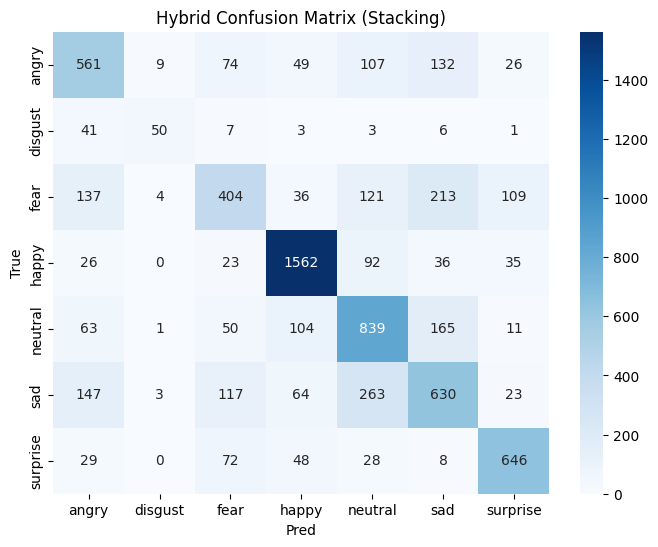


--- TEST Summary ---
               Model  Accuracy
0           ResNet18  0.652132
1         CNNEmotion  0.455837
2  Hybrid (Stacking)  0.653664


In [4]:
# --- Cell 4: Evaluate on TEST + Fusion chosen on VAL-META (alpha vs stacking) ---

from torch.amp import autocast
from sklearn.linear_model import LogisticRegression

def get_probs(model, loader):
    model.eval()
    all_labels=[]; all_probs=[]
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device); y=y.to(device)
            with autocast(device_type="cuda", enabled=(device.type=="cuda")):
                out=model(x)
                probs=torch.softmax(out,1)
            all_labels.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ---- 1) Get probs on val-meta (for selecting fusion) ----
probs1_val, y_val = get_probs(model_1, val_loader_meta)
probs2_val, _     = get_probs(model_2, val_loader_meta)

# Weighted alpha search on val-meta
best_alpha=None; best_acc_alpha=0; best_probs_alpha=None
for a in np.arange(0.6, 1.0, 0.05):
    hp = a*probs1_val + (1-a)*probs2_val
    acc = accuracy_score(y_val, hp.argmax(1))
    if acc>best_acc_alpha:
        best_acc_alpha=acc; best_alpha=a; best_probs_alpha=hp

print(f"[VAL] Best alpha fusion: alpha={best_alpha:.2f} acc={best_acc_alpha:.4f}")

# Stacking on val-meta
X_val_stack = np.concatenate([probs1_val, probs2_val], axis=1)
meta = LogisticRegression(max_iter=3000)
meta.fit(X_val_stack, y_val)
stack_val_preds = meta.predict(X_val_stack)
best_acc_stack = accuracy_score(y_val, stack_val_preds)

print(f"[VAL] Stacking fusion acc={best_acc_stack:.4f}")

# ---- 2) Choose fusion method ----
use_stacking = best_acc_stack > best_acc_alpha
fusion_name = "Stacking" if use_stacking else f"Alpha (a={best_alpha:.2f})"
print(f"\nChosen fusion method: {fusion_name}")

# ---- 3) Evaluate on TEST ----
probs1_test, y_test = get_probs(model_1, test_loader)
probs2_test, _      = get_probs(model_2, test_loader)

# Unimodals
acc_1 = accuracy_score(y_test, probs1_test.argmax(1))
acc_2 = accuracy_score(y_test, probs2_test.argmax(1))

print("\n--- TEST: ResNet18 ---", acc_1)
print("--- TEST: CNNEmotion ---", acc_2)

# Hybrid
if use_stacking:
    X_test_stack = np.concatenate([probs1_test, probs2_test], axis=1)
    hybrid_preds = meta.predict(X_test_stack)
else:
    hybrid_probs = best_alpha*probs1_test + (1-best_alpha)*probs2_test
    hybrid_preds = hybrid_probs.argmax(1)

hybrid_acc = accuracy_score(y_test, hybrid_preds)

print(f"\n--- TEST: Hybrid ({fusion_name}) --- {hybrid_acc:.4f}")
print(classification_report(y_test, hybrid_preds, target_names=class_labels, zero_division=0))

cm_hybrid = confusion_matrix(y_test, hybrid_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm_hybrid, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f"Hybrid Confusion Matrix ({fusion_name})")
plt.ylabel("True"); plt.xlabel("Pred")
plt.show()

results_df = pd.DataFrame({
    "Model": ["ResNet18", "CNNEmotion", f"Hybrid ({fusion_name})"],
    "Accuracy": [acc_1, acc_2, hybrid_acc]
})
print("\n--- TEST Summary ---")
print(results_df)



--- Training Curves ---


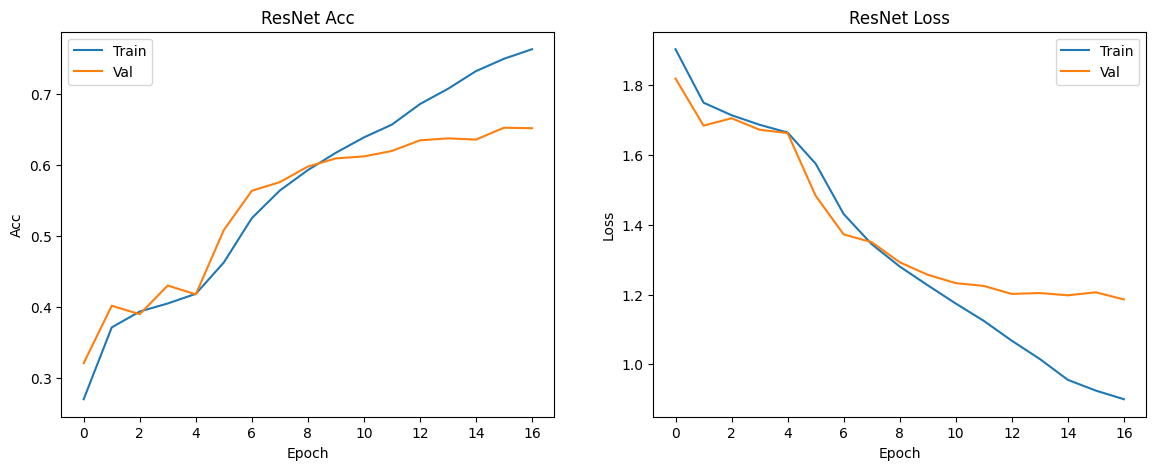

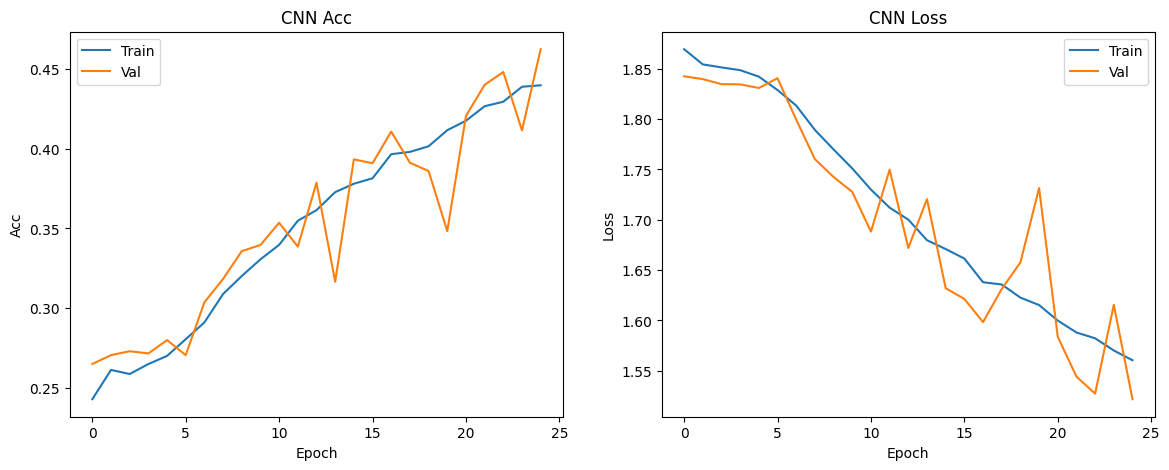


--- TEST Accuracy Summary ---
               Model  Accuracy
0           ResNet18  0.652132
1         CNNEmotion  0.455837
2  Hybrid (Stacking)  0.653664


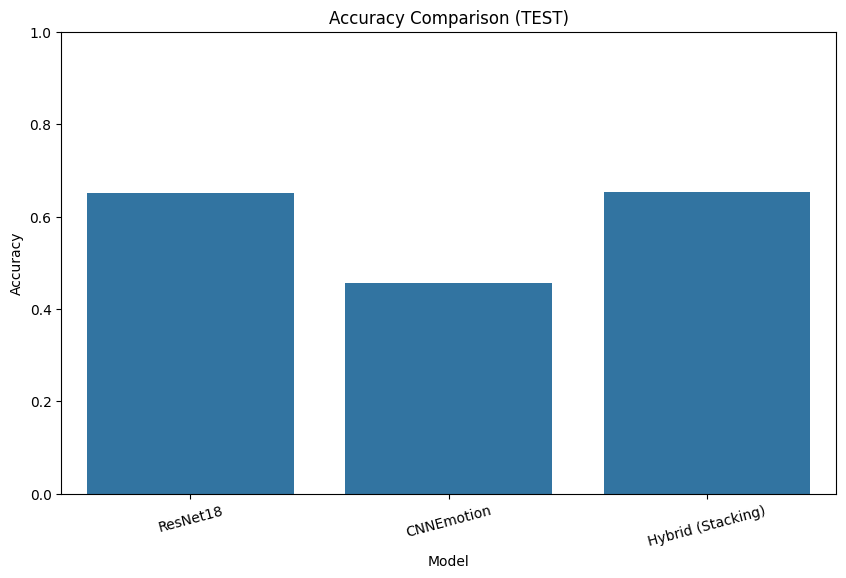

In [5]:
# --- Cell 5: Training Curves + Per-class F1 on TEST ---

print("\n--- Training Curves ---")

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_1["train_acc"]); plt.plot(history_1["val_acc"])
plt.title("ResNet Acc"); plt.legend(["Train","Val"]); plt.xlabel("Epoch"); plt.ylabel("Acc")

plt.subplot(1,2,2)
plt.plot(history_1["train_loss"]); plt.plot(history_1["val_loss"])
plt.title("ResNet Loss"); plt.legend(["Train","Val"]); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_2["train_acc"]); plt.plot(history_2["val_acc"])
plt.title("CNN Acc"); plt.legend(["Train","Val"]); plt.xlabel("Epoch"); plt.ylabel("Acc")

plt.subplot(1,2,2)
plt.plot(history_2["train_loss"]); plt.plot(history_2["val_loss"])
plt.title("CNN Loss"); plt.legend(["Train","Val"]); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()

print("\n--- TEST Accuracy Summary ---")
print(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Accuracy Comparison (TEST)")
plt.ylim(0,1); plt.xticks(rotation=15)
plt.show()
